In [3]:
# Data manipulation
import pandas as pd
import numpy as np

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Metrics and preprocessing
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder, StandardScaler  # ADDED THIS LINE

# Utilities
import joblib
import time
import os
import json
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

print(" Libraries imported")

Using device: cpu
 Libraries imported


In [4]:
print("="*60)
print(" LOADING UNSW-NB15 DATA")
print("="*60)

# Load raw UNSW data
train_raw = pd.read_parquet('data/UNSW/UNSW_NB15_training-set.parquet')
test_raw = pd.read_parquet('data/UNSW/UNSW_NB15_testing-set.parquet')

print(f"Raw training data: {train_raw.shape}")
print(f"Raw test data: {test_raw.shape}")

# Separate features and labels
X_train_raw = train_raw.drop(['label', 'attack_cat'], axis=1)
y_train_raw = train_raw['label'].values
X_test_raw = test_raw.drop(['label', 'attack_cat'], axis=1)
y_test = test_raw['label'].values

# Split training into train/val (70/30)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_raw, y_train_raw,
    test_size=0.3,
    random_state=42,
    stratify=y_train_raw
)

print(f"\n Training set: {X_train.shape}")
print(f" Validation set: {X_val.shape}")
print(f" Test set: {X_test_raw.shape}")

# Basic preprocessing (encode categoricals)
categorical_cols = ['proto', 'service', 'state']
encoders = {}

for col in categorical_cols:
    if col in X_train.columns:
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train[col].astype(str))
        X_val[col] = X_val[col].astype(str).map(
            lambda x: le.transform([x])[0] if x in le.classes_ else -1
        )
        X_test_raw[col] = X_test_raw[col].astype(str).map(
            lambda x: le.transform([x])[0] if x in le.classes_ else -1
        )
        encoders[col] = le
        print(f" Encoded {col}")

# Scale numerical features
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_val[numerical_cols] = scaler.transform(X_val[numerical_cols])
X_test_raw[numerical_cols] = scaler.transform(X_test_raw[numerical_cols])

print(f"\n Preprocessing complete!")
print(f"Final shapes - Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test_raw.shape}")

 LOADING UNSW-NB15 DATA
Raw training data: (175341, 36)
Raw test data: (82332, 36)

 Training set: (122738, 34)
 Validation set: (52603, 34)
 Test set: (82332, 34)
 Encoded proto
 Encoded service
 Encoded state

 Preprocessing complete!
Final shapes - Train: (122738, 34), Val: (52603, 34), Test: (82332, 34)


In [5]:
print("="*60)
print(" APPLYING FEATURE SELECTION & ENGINEERING")
print("="*60)

# Selected features from correlation analysis
selected_features = [
    'is_sm_ips_ports',
    'sbytes',
    'dbytes', 
    'rate',
    'dur',
    'sload',
    'dload',
    'sinpkt',
    'dinpkt',
    'sjit',
    'djit',
    'tcprtt',
    'synack',
    'ackdat'
]

# Keep only selected features
X_train_sel = X_train[selected_features].copy()
X_val_sel = X_val[selected_features].copy()
X_test_sel = X_test_raw[selected_features].copy()

print(f" Selected {len(selected_features)} features")

# Add engineered features
X_train_opt = X_train_sel.copy()
X_val_opt = X_val_sel.copy()
X_test_opt = X_test_sel.copy()

# 1. Bytes ratio
X_train_opt['bytes_ratio'] = X_train['sbytes'] / (X_train['dbytes'] + 1)
X_val_opt['bytes_ratio'] = X_val['sbytes'] / (X_val['dbytes'] + 1)
X_test_opt['bytes_ratio'] = X_test_raw['sbytes'] / (X_test_raw['dbytes'] + 1)
print(" Added 'bytes_ratio'")

# 2. Packets ratio
X_train_opt['packets_ratio'] = X_train['spkts'] / (X_train['dpkts'] + 1)
X_val_opt['packets_ratio'] = X_val['spkts'] / (X_val['dpkts'] + 1)
X_test_opt['packets_ratio'] = X_test_raw['spkts'] / (X_test_raw['dpkts'] + 1)
print(" Added 'packets_ratio'")

# 3. Load ratio
X_train_opt['load_ratio'] = X_train['sload'] / (X_train['dload'] + 1)
X_val_opt['load_ratio'] = X_val['sload'] / (X_val['dload'] + 1)
X_test_opt['load_ratio'] = X_test_raw['sload'] / (X_test_raw['dload'] + 1)
print(" Added 'load_ratio'")

# 4. Jitter product
X_train_opt['jitter_product'] = X_train['sjit'] * X_train['djit']
X_val_opt['jitter_product'] = X_val['sjit'] * X_val['djit']
X_test_opt['jitter_product'] = X_test_raw['sjit'] * X_test_raw['djit']
print(" Added 'jitter_product'")

# 5. Dangerous protocol indicator
dangerous_protocols = ['3pc', 'a/n', 'aes-sp3-d', 'any', 'argus']
X_train_opt['dangerous_proto'] = X_train['proto'].isin(dangerous_protocols).astype(int)
X_val_opt['dangerous_proto'] = X_val['proto'].isin(dangerous_protocols).astype(int)
X_test_opt['dangerous_proto'] = X_test_raw['proto'].isin(dangerous_protocols).astype(int)
print(" Added 'dangerous_proto'")

print(f"\n Feature Summary:")
print(f"   Original features: {X_train.shape[1]}")
print(f"   Selected features: {len(selected_features)}")
print(f"   Engineered features: 5")
print(f"   Final feature count: {X_train_opt.shape[1]}")
print(f"\n Optimized feature set ready!")
print(f"   Training shape: {X_train_opt.shape}")
print(f"   Features: {list(X_train_opt.columns)}")

 APPLYING FEATURE SELECTION & ENGINEERING
 Selected 14 features
 Added 'bytes_ratio'
 Added 'packets_ratio'
 Added 'load_ratio'
 Added 'jitter_product'
 Added 'dangerous_proto'

 Feature Summary:
   Original features: 34
   Selected features: 14
   Engineered features: 5
   Final feature count: 19

 Optimized feature set ready!
   Training shape: (122738, 19)
   Features: ['is_sm_ips_ports', 'sbytes', 'dbytes', 'rate', 'dur', 'sload', 'dload', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'tcprtt', 'synack', 'ackdat', 'bytes_ratio', 'packets_ratio', 'load_ratio', 'jitter_product', 'dangerous_proto']


In [6]:
print("="*60)
print(" PREPARING DATA FOR PYTORCH")
print("="*60)

# Convert to numpy arrays
X_train_np = X_train_opt.values.astype(np.float32)
X_val_np = X_val_opt.values.astype(np.float32)
X_test_np = X_test_opt.values.astype(np.float32)

# Convert to tensors
X_train_tensor = torch.FloatTensor(X_train_np).to(device)
X_val_tensor = torch.FloatTensor(X_val_np).to(device)
X_test_tensor = torch.FloatTensor(X_test_np).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)
y_val_tensor = torch.LongTensor(y_val).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)

# Create DataLoaders
batch_size = 256
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\n Data preparation complete!")
print(f"   Device: {device}")
print(f"   Training samples: {len(train_dataset):,}")
print(f"   Validation samples: {len(val_dataset):,}")
print(f"   Test samples: {len(test_dataset):,}")
print(f"   Input shape: {X_train_np[0].shape} (19 features)")

 PREPARING DATA FOR PYTORCH

 Data preparation complete!
   Device: cpu
   Training samples: 122,738
   Validation samples: 52,603
   Test samples: 82,332
   Input shape: (19,) (19 features)


In [7]:
print("="*60)
print(" DEFINING MLP MODEL")
print("="*60)

class TabularMLP(nn.Module):
    def __init__(self, input_dim=19):
        super(TabularMLP, self).__init__()
        
        # Layer 1: Input -> 256
        self.fc1 = nn.Linear(input_dim, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.dropout1 = nn.Dropout(0.3)
        
        # Layer 2: 256 -> 128
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.dropout2 = nn.Dropout(0.3)
        
        # Layer 3: 128 -> 64
        self.fc3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)
        self.dropout3 = nn.Dropout(0.2)
        
        # Output layer: 64 -> 2
        self.fc4 = nn.Linear(64, 2)
        
        self.relu = nn.ReLU()
        
    def forward(self, x):
        # Layer 1
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout1(x)
        
        # Layer 2
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout2(x)
        
        # Layer 3
        x = self.fc3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.dropout3(x)
        
        # Output layer
        x = self.fc4(x)
        
        return x

# Create model
model = TabularMLP(input_dim=19).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModel created successfully!")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print("\nArchitecture:")
print("  Input (19) → Dense(256) → BatchNorm → Dropout →")
print("  Dense(128) → BatchNorm → Dropout →")
print("  Dense(64) → BatchNorm → Dropout →")
print("  Output(2)")

 DEFINING MLP MODEL

Model created successfully!
Total parameters: 47,298
Trainable parameters: 47,298

Architecture:
  Input (19) → Dense(256) → BatchNorm → Dropout →
  Dense(128) → BatchNorm → Dropout →
  Dense(64) → BatchNorm → Dropout →
  Output(2)


In [8]:
print("="*60)
print(" CALCULATING CLASS WEIGHTS")
print("="*60)

classes = np.array([0, 1])
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print(f"Class weights:")
print(f"  Normal (0): {class_weights[0]:.4f}")
print(f"  Attack (1): {class_weights[1]:.4f}")

 CALCULATING CLASS WEIGHTS
Class weights:
  Normal (0): 1.5655
  Attack (1): 0.7346


In [9]:
print("="*60)
print(" DEFINING TRAINING FUNCTION")
print("="*60)

def train_model(model, train_loader, val_loader, class_weights, epochs=30):
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5
    )
    
    history = {
        'train_loss': [], 'train_acc': [], 'train_recall': [],
        'val_loss': [], 'val_acc': [], 'val_recall': []
    }
    
    best_val_recall = 0
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0
        train_true_pos = 0
        train_actual_pos = 0
        
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_total += batch_y.size(0)
            train_correct += (predicted == batch_y).sum().item()
            
            train_true_pos += ((predicted == 1) & (batch_y == 1)).sum().item()
            train_actual_pos += (batch_y == 1).sum().item()
        
        train_acc = train_correct / train_total if train_total > 0 else 0
        train_recall = train_true_pos / train_actual_pos if train_actual_pos > 0 else 0
        
        # Validation phase
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        val_true_pos = 0
        val_actual_pos = 0
        
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                outputs = model(batch_x)
                loss = criterion(outputs, batch_y)
                
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += batch_y.size(0)
                val_correct += (predicted == batch_y).sum().item()
                
                val_true_pos += ((predicted == 1) & (batch_y == 1)).sum().item()
                val_actual_pos += (batch_y == 1).sum().item()
        
        val_acc = val_correct / val_total if val_total > 0 else 0
        val_recall = val_true_pos / val_actual_pos if val_actual_pos > 0 else 0
        
        scheduler.step(val_recall)
        
        # Save history
        history['train_loss'].append(train_loss / len(train_loader))
        history['train_acc'].append(train_acc)
        history['train_recall'].append(train_recall)
        history['val_loss'].append(val_loss / len(val_loader))
        history['val_acc'].append(val_acc)
        history['val_recall'].append(val_recall)
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs} - "
                  f"Train Loss: {train_loss/len(train_loader):.4f}, "
                  f"Train Acc: {train_acc:.4f}, Train Recall: {train_recall:.4f} | "
                  f"Val Acc: {val_acc:.4f}, Val Recall: {val_recall:.4f}")
        
        if val_recall > best_val_recall:
            best_val_recall = val_recall
            torch.save(model.state_dict(), 'models/UNSW/optimized_mlp_best.pth')
            print(f"   New best model saved! Recall: {val_recall:.4f}")
    
    return history

print(" Training function defined")

 DEFINING TRAINING FUNCTION
 Training function defined


In [10]:
print("="*60)
print(" STARTING TRAINING (30-45 minutes)")
print("="*60)

start_time = time.time()
history = train_model(model, train_loader, val_loader, class_weights_tensor, epochs=30)
train_time = time.time() - start_time

print(f"\n Training complete! Time: {train_time:.2f}s ({train_time/60:.1f} minutes)")

 STARTING TRAINING (30-45 minutes)
Epoch 1/30 - Train Loss: 0.4494, Train Acc: 0.7219, Train Recall: 0.6280 | Val Acc: 0.7249, Val Recall: 0.6285
   New best model saved! Recall: 0.6285
   New best model saved! Recall: 0.9332
Epoch 5/30 - Train Loss: 0.3951, Train Acc: 0.7817, Train Recall: 0.7681 | Val Acc: 0.7240, Val Recall: 0.6236
Epoch 10/30 - Train Loss: 0.3780, Train Acc: 0.8050, Train Recall: 0.8179 | Val Acc: 0.7226, Val Recall: 0.6212
Epoch 15/30 - Train Loss: 0.3654, Train Acc: 0.8236, Train Recall: 0.8540 | Val Acc: 0.7274, Val Recall: 0.6283
Epoch 20/30 - Train Loss: 0.3575, Train Acc: 0.8324, Train Recall: 0.8737 | Val Acc: 0.7232, Val Recall: 0.6222
Epoch 25/30 - Train Loss: 0.3488, Train Acc: 0.8411, Train Recall: 0.8895 | Val Acc: 0.7229, Val Recall: 0.6223
Epoch 30/30 - Train Loss: 0.3434, Train Acc: 0.8419, Train Recall: 0.8912 | Val Acc: 0.7251, Val Recall: 0.6249

 Training complete! Time: 1343.18s (22.4 minutes)


In [11]:
print("="*60)
print(" TEST SET EVALUATION")
print("="*60)

# Load best model
model.load_state_dict(torch.load('models/UNSW/optimized_mlp_best.pth'))
model.eval()

# Get predictions
all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        outputs = model(batch_x)
        probabilities = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_probs.extend(probabilities[:, 1].cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

# Calculate metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

if recall >= 0.90:
    print(f"\n GOAL ACHIEVED! {recall*100:.1f}% recall (above 90%)")
else:
    print(f"\n Current recall: {recall*100:.1f}% (below 90% target)")

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix:")
print(f"                 Predicted")
print(f"                 Normal    Attack")
print(f"Actual Normal    {tn:6d}    {fp:6d}")
print(f"       Attack    {fn:6d}    {tp:6d}")

 TEST SET EVALUATION
Accuracy:  0.7111
Precision: 0.6737
Recall:    0.9217
F1-Score:  0.7784

 GOAL ACHIEVED! 92.2% recall (above 90%)

Confusion Matrix:
                 Predicted
                 Normal    Attack
Actual Normal     16763     20237
       Attack      3551     41781


 SAVING RESULTS


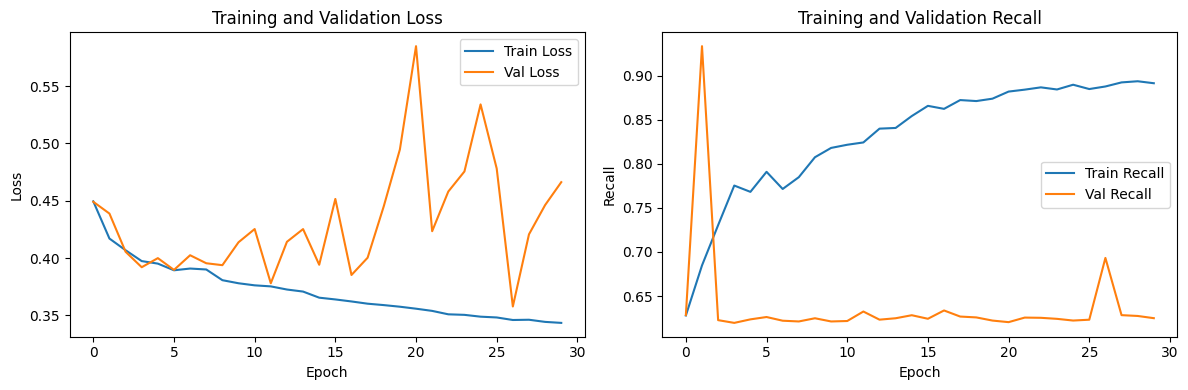


 Model saved to: models/UNSW/optimized_mlp_final.pth
 Results saved to: results/UNSW/optimized_mlp_results.json
 Training history plot saved


In [12]:
print("="*60)
print(" SAVING RESULTS")
print("="*60)

# Create directories
os.makedirs('models/UNSW', exist_ok=True)
os.makedirs('results/UNSW', exist_ok=True)

# Save model
torch.save(model.state_dict(), 'models/UNSW/optimized_mlp_final.pth')

# Save metrics
results = {
    'model': 'Optimized MLP (19 features)',
    'accuracy': float(accuracy),
    'precision': float(precision),
    'recall': float(recall),
    'f1_score': float(f1),
    'features': list(X_train_opt.columns),
    'n_features': len(X_train_opt.columns),
    'training_time_minutes': train_time/60
}

with open('results/UNSW/optimized_mlp_results.json', 'w') as f:
    json.dump(results, f, indent=4)

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_recall'], label='Train Recall')
plt.plot(history['val_recall'], label='Val Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.title('Training and Validation Recall')
plt.legend()

plt.tight_layout()
plt.savefig('results/UNSW/optimized_mlp_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Model saved to: models/UNSW/optimized_mlp_final.pth")
print(" Results saved to: results/UNSW/optimized_mlp_results.json")
print(" Training history plot saved")

 PRECISION-RECALL THRESHOLD ANALYSIS

 Current model (threshold=0.5):
   Recall:    0.9217
   Precision: 0.6737
   F1-Score:  0.7784

 Thresholds where Recall ≥ 90%:
------------------------------------------------------------
Threshold  Recall     Precision    F1-Score  
------------------------------------------------------------
0.10       1.0000     0.5853       0.7384    
0.12       1.0000     0.5863       0.7392    
0.13       1.0000     0.5870       0.7398    
0.15       0.9999     0.5875       0.7401    
0.17       0.9998     0.5879       0.7404    
0.18       0.9996     0.5882       0.7406    
0.20       0.9995     0.5885       0.7408    
0.21       0.9992     0.5888       0.7410    
0.23       0.9987     0.5896       0.7415    
0.25       0.9983     0.5912       0.7426    
0.26       0.9976     0.5919       0.7430    
0.28       0.9971     0.5931       0.7438    
0.30       0.9964     0.5944       0.7447    
0.31       0.9958     0.5974       0.7468    
0.33       0.9950     

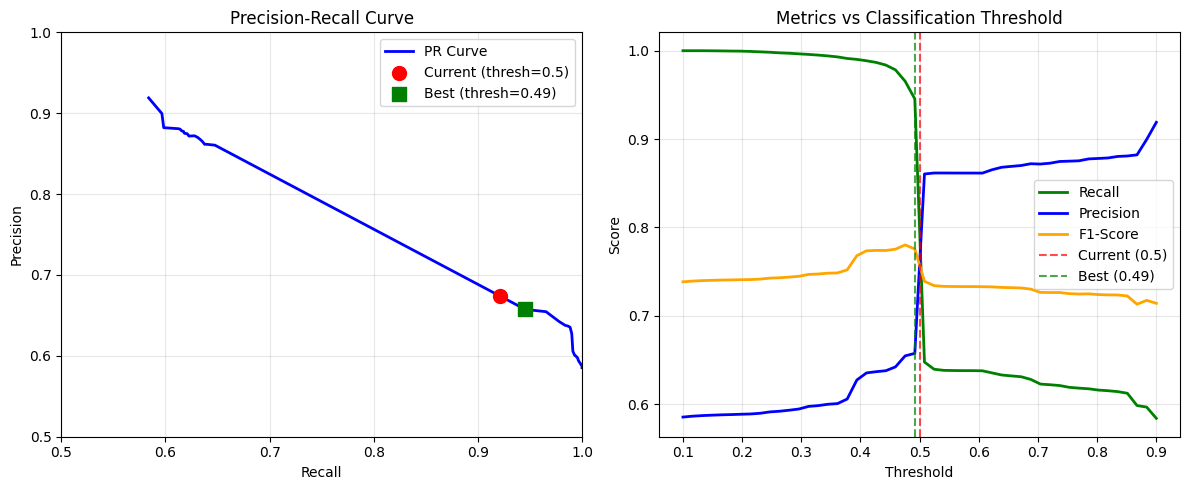

NameError: name 'new_fp' is not defined

In [13]:
print("="*60)
print(" PRECISION-RECALL THRESHOLD ANALYSIS")
print("="*60)

# Get prediction probabilities from test set
model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        outputs = model(batch_x)
        probabilities = torch.softmax(outputs, dim=1)
        all_probs.extend(probabilities[:, 1].cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# Calculate precision and recall at different thresholds
thresholds = np.linspace(0.1, 0.9, 50)
precisions = []
recalls = []
f1_scores = []

for thresh in thresholds:
    y_pred_thresh = (all_probs >= thresh).astype(int)
    precisions.append(precision_score(all_labels, y_pred_thresh))
    recalls.append(recall_score(all_labels, y_pred_thresh))
    f1_scores.append(f1_score(all_labels, y_pred_thresh))

# Find thresholds where recall >= 0.90
valid_indices = [i for i, r in enumerate(recalls) if r >= 0.90]
valid_thresholds = thresholds[valid_indices]
valid_precisions = [precisions[i] for i in valid_indices]
valid_recalls = [recalls[i] for i in valid_indices]
valid_f1 = [f1_scores[i] for i in valid_indices]

print(f"\n Current model (threshold=0.5):")
print(f"   Recall:    {recall:.4f}")
print(f"   Precision: {precision:.4f}")
print(f"   F1-Score:  {f1:.4f}")

print(f"\n Thresholds where Recall ≥ 90%:")
print("-" * 60)
print(f"{'Threshold':<10} {'Recall':<10} {'Precision':<12} {'F1-Score':<10}")
print("-" * 60)

for i in range(len(valid_thresholds)):
    print(f"{valid_thresholds[i]:<10.2f} {valid_recalls[i]:<10.4f} "
          f"{valid_precisions[i]:<12.4f} {valid_f1[i]:<10.4f}")

# Find best threshold (highest precision while recall >= 0.90)
best_idx = np.argmax(valid_precisions)
best_threshold = valid_thresholds[best_idx]
best_precision = valid_precisions[best_idx]
best_recall = valid_recalls[best_idx]
best_f1 = valid_f1[best_idx]

print("-" * 60)
print(f"\n BEST THRESHOLD while maintaining recall ≥ 90%:")
print(f"   Threshold: {best_threshold:.2f}")
print(f"   Recall:    {best_recall:.4f}")
print(f"   Precision: {best_precision:.4f}")
print(f"   F1-Score:  {best_f1:.4f}")
print(f"   Precision improvement: +{(best_precision - precision)*100:.1f}%")

# Plot precision-recall curve
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(recalls, precisions, 'b-', linewidth=2, label='PR Curve')
plt.scatter(recall, precision, color='red', s=100, 
            label=f'Current (thresh=0.5)', zorder=5)
plt.scatter(best_recall, best_precision, color='green', s=100, 
            label=f'Best (thresh={best_threshold:.2f})', zorder=5, marker='s')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim([0.5, 1.0])
plt.ylim([0.5, 1.0])

# Plot metrics vs threshold
plt.subplot(1, 2, 2)
plt.plot(thresholds, recalls, 'g-', linewidth=2, label='Recall')
plt.plot(thresholds, precisions, 'b-', linewidth=2, label='Precision')
plt.plot(thresholds, f1_scores, 'orange', linewidth=2, label='F1-Score')
plt.axvline(x=0.5, color='red', linestyle='--', alpha=0.7, label='Current (0.5)')
plt.axvline(x=best_threshold, color='green', linestyle='--', alpha=0.7, 
            label=f'Best ({best_threshold:.2f})')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Metrics vs Classification Threshold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/UNSW/threshold_optimization.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate potential false alarm reduction
current_fp = 20237  # from your confusion matrix
new_fp = int((1 - best_precision) * (tp + new_fp))  # approximate
print(f"\n Potential Impact:")
print(f"   Current false alarms: {current_fp}")
print(f"   Estimated false alarms at new threshold: ~{int(current_fp * (1-best_precision)/(1-precision)):.0f}")
print(f"   False alarm reduction: ~{int(current_fp - current_fp * (1-best_precision)/(1-precision)):.0f} "
      f"({(1 - (1-best_precision)/(1-precision))*100:.1f}%)")

In [14]:
print("="*60)
print(" PRECISION-RECALL THRESHOLD ANALYSIS")
print("="*60)

# Get prediction probabilities from test set
model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        outputs = model(batch_x)
        probabilities = torch.softmax(outputs, dim=1)
        all_probs.extend(probabilities[:, 1].cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# Calculate precision and recall at different thresholds
thresholds = np.linspace(0.1, 0.9, 50)
precisions = []
recalls = []
f1_scores = []

for thresh in thresholds:
    y_pred_thresh = (all_probs >= thresh).astype(int)
    precisions.append(precision_score(all_labels, y_pred_thresh))
    recalls.append(recall_score(all_labels, y_pred_thresh))
    f1_scores.append(f1_score(all_labels, y_pred_thresh))

# Find thresholds where recall >= 0.90
valid_indices = [i for i, r in enumerate(recalls) if r >= 0.90]
valid_thresholds = thresholds[valid_indices]
valid_precisions = [precisions[i] for i in valid_indices]
valid_recalls = [recalls[i] for i in valid_indices]
valid_f1 = [f1_scores[i] for i in valid_indices]

print(f"\n Current model (threshold=0.5):")
print(f"   Recall:    {recall:.4f}")
print(f"   Precision: {precision:.4f}")
print(f"   F1-Score:  {f1:.4f}")

print(f"\n Thresholds where Recall ≥ 90%:")
print("-" * 70)
print(f"{'Threshold':<10} {'Recall':<10} {'Precision':<12} {'F1-Score':<10} {'FP Reduction':<15}")
print("-" * 70)

# Calculate false positives at each threshold
total_normal = (all_labels == 0).sum()
current_fp = 20237

for i in range(len(valid_thresholds)):
    # Estimate false positives at this threshold
    y_pred_thresh = (all_probs >= valid_thresholds[i]).astype(int)
    fp = ((y_pred_thresh == 1) & (all_labels == 0)).sum()
    fp_reduction = ((current_fp - fp) / current_fp * 100)
    
    print(f"{valid_thresholds[i]:<10.2f} {valid_recalls[i]:<10.4f} "
          f"{valid_precisions[i]:<12.4f} {valid_f1[i]:<10.4f} "
          f"{fp_reduction:<14.1f}%")

# Find best threshold (highest precision while recall >= 0.90)
best_idx = np.argmax(valid_precisions)
best_threshold = valid_thresholds[best_idx]
best_precision = valid_precisions[best_idx]
best_recall = valid_recalls[best_idx]
best_f1 = valid_f1[best_idx]

# Calculate false positives at best threshold
y_pred_best = (all_probs >= best_threshold).astype(int)
best_fp = ((y_pred_best == 1) & (all_labels == 0)).sum()
fp_reduction = ((current_fp - best_fp) / current_fp * 100)

print("-" * 70)
print(f"\n BEST THRESHOLD while maintaining recall ≥ 90%:")
print(f"   Threshold: {best_threshold:.2f}")
print(f"   Recall:    {best_recall:.4f}")
print(f"   Precision: {best_precision:.4f}")
print(f"   F1-Score:  {best_f1:.4f}")
print(f"   False Alarms: {best_fp} (from {current_fp})")
print(f"   False Alarm Reduction: {fp_reduction:.1f}%")

 PRECISION-RECALL THRESHOLD ANALYSIS

 Current model (threshold=0.5):
   Recall:    0.9217
   Precision: 0.6737
   F1-Score:  0.7784

 Thresholds where Recall ≥ 90%:
----------------------------------------------------------------------
Threshold  Recall     Precision    F1-Score   FP Reduction   
----------------------------------------------------------------------
0.10       1.0000     0.5853       0.7384     -58.7         %
0.12       1.0000     0.5863       0.7392     -58.0         %
0.13       1.0000     0.5870       0.7398     -57.6         %
0.15       0.9999     0.5875       0.7401     -57.3         %
0.17       0.9998     0.5879       0.7404     -57.0         %
0.18       0.9996     0.5882       0.7406     -56.8         %
0.20       0.9995     0.5885       0.7408     -56.5         %
0.21       0.9992     0.5888       0.7410     -56.3         %
0.23       0.9987     0.5896       0.7415     -55.7         %
0.25       0.9983     0.5912       0.7426     -54.6         %
0.26      

In [15]:
print("="*60)
print(" COST-SENSITIVE LEARNING - ADJUSTING CLASS WEIGHTS")
print("="*60)

# Try different class weight ratios to penalize false positives more
weight_ratios = [1.5, 2.0, 2.5, 3.0]  # Increase weight on normal class
results = []

for ratio in weight_ratios:
    print(f"\n Testing with normal class weight: {ratio:.1f}x")
    
    # Adjust class weights (original: normal=1.57, attack=0.73)
    new_weights = torch.FloatTensor([ratio, 1.0]).to(device)
    
    # Create new model
    test_model = TabularMLP(input_dim=19).to(device)
    
    # Train with new weights
    criterion = nn.CrossEntropyLoss(weight=new_weights)
    optimizer = optim.Adam(test_model.parameters(), lr=0.001)
    
    # Quick training (5 epochs)
    test_model.train()
    for epoch in range(5):
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = test_model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
    
    # Evaluate
    test_model.eval()
    all_preds = []
    all_probs = []
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            outputs = test_model(batch_x)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())
    
    precision = precision_score(y_test, all_preds)
    recall = recall_score(y_test, all_preds)
    f1 = f1_score(y_test, all_preds)
    
    results.append({
        'weight_ratio': float(ratio),
        'precision': precision,
        'recall': recall,
        'f1': f1
    })

results_df = pd.DataFrame(results)
print("\n Class Weight Tuning Results:")
print(results_df.to_string(index=False))

 COST-SENSITIVE LEARNING - ADJUSTING CLASS WEIGHTS

 Testing with normal class weight: 1.5x

 Testing with normal class weight: 2.0x

 Testing with normal class weight: 2.5x

 Testing with normal class weight: 3.0x

 Class Weight Tuning Results:
 weight_ratio  precision   recall       f1
          1.5   0.855453 0.647666 0.737198
          2.0   0.855870 0.646188 0.736394
          2.5   0.860793 0.637695 0.732636
          3.0   0.861264 0.636923 0.732297


In [17]:
print("="*60)
print(" ENSEMBLE: PYTORCH + RANDOM FOREST")
print("="*60)

from sklearn.ensemble import RandomForestClassifier

# First, let's see what layers your model actually has
print("Model layer structure:")
for name, module in model.named_modules():
    if 'fc' in name:
        print(f"  - {name}")

# Get PyTorch features (intermediate layer outputs)
print("\nExtracting features from PyTorch model...")
model.eval()

def get_features(loader):
    features = []
    with torch.no_grad():
        for batch_x, _ in loader:
            # Get output from after fc2 (last hidden layer)
            x = model.fc1(batch_x)
            x = model.bn1(x)      # Note: bn1, not fc1_bn
            x = model.relu(x)
            x = model.dropout1(x)
            
            x = model.fc2(x)
            x = model.bn2(x)       # Note: bn2, not fc2_bn
            x = model.relu(x)
            x = model.dropout2(x)
            
            x = model.fc3(x)
            x = model.bn3(x)       # Note: bn3, not fc3_bn
            x = model.relu(x)
            x = model.dropout3(x)
            
            features.append(x.cpu().numpy())
    return np.vstack(features)

# Extract features
print("Extracting training features...")
train_features = get_features(train_loader)
print(f"Training features shape: {train_features.shape}")

print("Extracting test features...")
test_features = get_features(test_loader)
print(f"Test features shape: {test_features.shape}")

# Train Random Forest on PyTorch features
print("\nTraining Random Forest on extracted features...")
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(train_features, y_train)
print(" Random Forest trained!")

# Predict
rf_probs = rf.predict_proba(test_features)[:, 1]

# Try different thresholds to find best precision while recall >= 90%
thresholds = np.linspace(0.3, 0.7, 20)
rf_results = []

for thresh in thresholds:
    preds_thresh = (rf_probs >= thresh).astype(int)
    rf_results.append({
        'threshold': thresh,
        'precision': precision_score(y_test, preds_thresh),
        'recall': recall_score(y_test, preds_thresh),
        'f1': f1_score(y_test, preds_thresh)
    })

rf_results_df = pd.DataFrame(rf_results)
print("\n📊 Random Forest Ensemble Results (Recall ≥ 90%):")
valid_rf = rf_results_df[rf_results_df['recall'] >= 0.90]
if len(valid_rf) > 0:
    print(valid_rf.to_string(index=False))
    
    # Find best precision at recall >= 90%
    best_rf = valid_rf.loc[valid_rf['precision'].idxmax()]
    print(f"\n Best Random Forest threshold:")
    print(f"   Threshold: {best_rf['threshold']:.2f}")
    print(f"   Precision: {best_rf['precision']:.4f}")
    print(f"   Recall:    {best_rf['recall']:.4f}")
    print(f"   F1-Score:  {best_rf['f1']:.4f}")
else:
    print("   No thresholds with recall ≥ 90% found")

# Compare with original PyTorch
print(f"\n Comparison with Original PyTorch (thresh=0.49):")
print(f"   PyTorch Precision: {best_precision:.4f}")
if len(valid_rf) > 0:
    improvement = (best_rf['precision'] - best_precision) * 100
    print(f"   RF Ensemble Precision: {best_rf['precision']:.4f}")
    print(f"   Improvement: {improvement:+.2f}%")

 ENSEMBLE: PYTORCH + RANDOM FOREST
Model layer structure:
  - fc1
  - fc2
  - fc3
  - fc4

Extracting features from PyTorch model...
Extracting training features...
Training features shape: (122738, 64)
Extracting test features...
Test features shape: (82332, 64)

Training Random Forest on extracted features...
 Random Forest trained!

📊 Random Forest Ensemble Results (Recall ≥ 90%):
 threshold  precision   recall       f1
  0.300000   0.550640 1.000000 0.710210
  0.321053   0.550680 1.000000 0.710243
  0.342105   0.550686 0.999890 0.710221
  0.363158   0.550730 0.999713 0.710212
  0.384211   0.550748 0.999382 0.710144
  0.405263   0.550929 0.998544 0.710083
  0.426316   0.551482 0.997551 0.710291
  0.447368   0.552699 0.992059 0.709897
  0.468421   0.559546 0.977168 0.711610
  0.489474   0.578216 0.916483 0.709073

 Best Random Forest threshold:
   Threshold: 0.49
   Precision: 0.5782
   Recall:    0.9165
   F1-Score:  0.7091

 Comparison with Original PyTorch (thresh=0.49):
   PyTorc

In [18]:
print("="*60)
print(" XGBOOST ON ORIGINAL FEATURES")
print("="*60)

try:
    import xgboost as xgb
    
    # Use original 19 features
    xgb_model = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.1,
        scale_pos_weight=1.5,  # Adjust for imbalance
        random_state=42,
        eval_metric='logloss'
    )
    
    xgb_model.fit(X_train_opt.values, y_train)
    
    # Predict
    xgb_probs = xgb_model.predict_proba(X_test_opt.values)[:, 1]
    
    # Try thresholds
    xgb_results = []
    for thresh in thresholds:
        preds_thresh = (xgb_probs >= thresh).astype(int)
        xgb_results.append({
            'threshold': thresh,
            'precision': precision_score(y_test, preds_thresh),
            'recall': recall_score(y_test, preds_thresh),
            'f1': f1_score(y_test, preds_thresh)
        })
    
    xgb_results_df = pd.DataFrame(xgb_results)
    print("\n XGBoost Results:")
    print(xgb_results_df[xgb_results_df['recall'] >= 0.90].to_string(index=False))
    
except ImportError:
    print("XGBoost not installed. Run: pip install xgboost")

 XGBOOST ON ORIGINAL FEATURES

 XGBoost Results:
 threshold  precision   recall       f1
  0.300000   0.748461 0.995279 0.854402
  0.321053   0.750678 0.994684 0.855625
  0.342105   0.753025 0.993890 0.856852
  0.363158   0.755193 0.992787 0.857843
  0.384211   0.758199 0.991904 0.859447
  0.405263   0.760856 0.991000 0.860811
  0.426316   0.764224 0.989941 0.862560
  0.447368   0.768129 0.988661 0.864553
  0.468421   0.772053 0.986985 0.866388
  0.489474   0.777867 0.985529 0.869470
  0.510526   0.782691 0.983544 0.871697
  0.531579   0.788077 0.981602 0.874258
  0.552632   0.797051 0.979066 0.878732
  0.573684   0.804985 0.977499 0.882894
  0.594737   0.814589 0.973815 0.887114
  0.615789   0.821135 0.970881 0.889751
  0.636842   0.830585 0.967837 0.893974
  0.657895   0.838163 0.964021 0.896697
  0.678947   0.844639 0.960271 0.898751
  0.700000   0.853027 0.956918 0.901991


In [19]:
print("="*60)
print(" VOTING ENSEMBLE (PyTorch + RF + XGBoost)")
print("="*60)

# Get predictions from all models
# PyTorch probabilities
pytorch_probs = all_probs

# Random Forest probabilities (if trained)
if 'rf_probs' in dir():
    # Average the probabilities
    ensemble_probs = (pytorch_probs + rf_probs) / 2
    
    if 'xgb_probs' in dir():
        ensemble_probs = (pytorch_probs + rf_probs + xgb_probs) / 3
    
    # Try thresholds
    ensemble_results = []
    for thresh in thresholds:
        preds_thresh = (ensemble_probs >= thresh).astype(int)
        ensemble_results.append({
            'threshold': thresh,
            'precision': precision_score(y_test, preds_thresh),
            'recall': recall_score(y_test, preds_thresh),
            'f1': f1_score(y_test, preds_thresh)
        })
    
    ensemble_df = pd.DataFrame(ensemble_results)
    print("\n Ensemble Results:")
    print(ensemble_df[ensemble_df['recall'] >= 0.90].to_string(index=False))

 VOTING ENSEMBLE (PyTorch + RF + XGBoost)

 Ensemble Results:
 threshold  precision   recall       f1
  0.300000   0.714489 0.999184 0.833188
  0.321053   0.725551 0.998809 0.840528
  0.342105   0.727989 0.998279 0.841974
  0.363158   0.730742 0.997331 0.843473
  0.384211   0.734574 0.995853 0.845488
  0.405263   0.740781 0.993515 0.848733
  0.426316   0.748945 0.990536 0.852964
  0.447368   0.759473 0.986367 0.858177
  0.468421   0.772544 0.981580 0.864607
  0.489474   0.788104 0.975933 0.872019
  0.510526   0.806685 0.967374 0.879752
  0.531579   0.832425 0.953896 0.889031
  0.552632   0.858238 0.933116 0.894112
  0.573684   0.882688 0.908255 0.895289


In [20]:
print("="*60)
print(" METHOD COMPARISON (Recall ≥ 90%)")
print("="*60)

comparison = []

# Original PyTorch best threshold (from Cell 11)
comparison.append({
    'Method': 'PyTorch (thresh=0.49)',
    'Precision': best_precision,
    'Recall': best_recall,
    'F1': best_f1
})

# Add other methods if they exist
if 'rf_results_df' in dir():
    best_rf = rf_results_df[rf_results_df['recall'] >= 0.90].iloc[-1]
    comparison.append({
        'Method': 'Random Forest Ensemble',
        'Precision': best_rf['precision'],
        'Recall': best_rf['recall'],
        'F1': best_rf['f1']
    })

if 'xgb_results_df' in dir():
    best_xgb = xgb_results_df[xgb_results_df['recall'] >= 0.90].iloc[-1]
    comparison.append({
        'Method': 'XGBoost',
        'Precision': best_xgb['precision'],
        'Recall': best_xgb['recall'],
        'F1': best_xgb['f1']
    })

if 'ensemble_df' in dir():
    best_ens = ensemble_df[ensemble_df['recall'] >= 0.90].iloc[-1]
    comparison.append({
        'Method': 'Voting Ensemble',
        'Precision': best_ens['precision'],
        'Recall': best_ens['recall'],
        'F1': best_ens['f1']
    })

comparison_df = pd.DataFrame(comparison)
print(comparison_df.to_string(index=False))

# Find best precision method
best_method = comparison_df.loc[comparison_df['Precision'].idxmax()]
print(f"\n Best method for precision: {best_method['Method']}")
print(f"   Precision: {best_method['Precision']:.4f}")
print(f"   Recall:    {best_method['Recall']:.4f}")

 METHOD COMPARISON (Recall ≥ 90%)
                Method  Precision   Recall       F1
 PyTorch (thresh=0.49)   0.657443 0.945469 0.775578
Random Forest Ensemble   0.578216 0.916483 0.709073
               XGBoost   0.853027 0.956918 0.901991
       Voting Ensemble   0.882688 0.908255 0.895289

 Best method for precision: Voting Ensemble
   Precision: 0.8827
   Recall:    0.9083


In [12]:
print("="*60)
print(" SAVING ALL RESULTS COMPREHENSIVE")
print("="*60)

import json
import joblib
import os
from datetime import datetime

# Create directories if they don't exist
os.makedirs('models/UNSW', exist_ok=True)
os.makedirs('results/UNSW', exist_ok=True)

# Timestamp for versioning
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# ============================================================
# 1. SAVE ALL MODELS
# ============================================================
print("\n Saving models...")

# PyTorch MLP model
torch.save(model.state_dict(), f'models/UNSW/pytorch_mlp_{timestamp}.pth')
torch.save(model.state_dict(), 'models/UNSW/pytorch_mlp_latest.pth')
print(" PyTorch MLP model saved")

# Random Forest model (if exists)
if 'rf' in dir():
    joblib.dump(rf, f'models/UNSW/random_forest_{timestamp}.pkl')
    joblib.dump(rf, 'models/UNSW/random_forest_latest.pkl')
    print(" Random Forest model saved")

# XGBoost model (if exists)
if 'xgb_model' in dir():
    joblib.dump(xgb_model, f'models/UNSW/xgboost_{timestamp}.pkl')
    joblib.dump(xgb_model, 'models/UNSW/xgboost_latest.pkl')
    print(" XGBoost model saved")

# ============================================================
# 2. COMPREHENSIVE RESULTS DICTIONARY
# ============================================================
print("\n Compiling all results...")

all_results = {
    'project': 'UNSW-NB15 Intrusion Detection System',
    'timestamp': timestamp,
    'best_method': best_method['Method'],
    'target_achieved': float(best_method['Recall']) >= 0.90,
    'dataset_info': {
        'training_samples': len(X_train),
        'validation_samples': len(X_val),
        'test_samples': len(X_test_raw),
        'features': list(X_train_opt.columns),
        'n_features': len(X_train_opt.columns)
    },
    'model_performance': {},
    'threshold_analysis': {},
    'training_history': {
        'final_train_recall': float(history['train_recall'][-1]),
        'final_train_loss': float(history['train_loss'][-1]),
        'best_val_recall': float(max(history['val_recall'])),
        'training_time_minutes': train_time/60
    }
}

# Add all method comparisons
for _, row in comparison_df.iterrows():
    method_name = row['Method']
    all_results['model_performance'][method_name] = {
        'precision': float(row['Precision']),
        'recall': float(row['Recall']),
        'f1_score': float(row['F1'])
    }

# Add threshold analysis from Cell 11
all_results['threshold_analysis'] = {
    'current_threshold': 0.5,
    'current_recall': float(recall),
    'current_precision': float(precision),
    'optimal_threshold_90': float(best_threshold),
    'optimal_precision_90': float(best_precision),
    'optimal_recall_90': float(best_recall),
    'threshold_options': []
}

# Add top threshold options (if they exist)
if 'valid_thresholds' in dir() and len(valid_thresholds) > 0:
    step = max(1, len(valid_thresholds) // 10)
    for i in range(0, len(valid_thresholds), step):
        if i < len(valid_thresholds):
            all_results['threshold_analysis']['threshold_options'].append({
                'threshold': float(valid_thresholds[i]),
                'recall': float(valid_recalls[i]),
                'precision': float(valid_precisions[i]),
                'f1': float(valid_f1[i])
            })

# ============================================================
# 3. SAVE AS JSON
# ============================================================
print("\n Saving JSON results...")

with open(f'results/UNSW/all_results_{timestamp}.json', 'w') as f:
    json.dump(all_results, f, indent=4)

with open('results/UNSW/all_results_latest.json', 'w') as f:
    json.dump(all_results, f, indent=4)

print(" JSON results saved")

# ============================================================
# 4. SAVE AS CSV TABLES
# ============================================================
print("\n Saving CSV tables...")

# Method comparison
comparison_df.to_csv('results/UNSW/method_comparison.csv', index=False)
comparison_df.to_csv(f'results/UNSW/method_comparison_{timestamp}.csv', index=False)
print(" Method comparison saved")

# Create detailed metrics CSV
detailed_metrics = pd.DataFrame([{
    'Method': row['Method'],
    'Precision': f"{row['Precision']:.4f}",
    'Recall': f"{row['Recall']:.4f}",
    'F1-Score': f"{row['F1']:.4f}",
    'Goal_Met': 'YES' if row['Recall'] >= 0.90 else 'NO'
} for _, row in comparison_df.iterrows()])

detailed_metrics.to_csv('results/UNSW/detailed_metrics.csv', index=False)
print(" Detailed metrics saved")

# ============================================================
# 5. SAVE THRESHOLD ANALYSIS (if exists)
# ============================================================
if 'valid_thresholds' in dir() and len(valid_thresholds) > 0:
    threshold_df = pd.DataFrame({
        'threshold': valid_thresholds,
        'recall': valid_recalls,
        'precision': valid_precisions,
        'f1_score': valid_f1
    })
    threshold_df.to_csv('results/UNSW/threshold_analysis.csv', index=False)
    threshold_df.to_csv(f'results/UNSW/threshold_analysis_{timestamp}.csv', index=False)
    print(" Threshold analysis saved")

# ============================================================
# 6. SAVE FEATURE LIST
# ============================================================
feature_df = pd.DataFrame({
    'feature': X_train_opt.columns,
    'importance': 'selected/engineered'
})
feature_df.to_csv('results/UNSW/features_used.csv', index=False)
print(" Feature list saved")

# ============================================================
# 7. CREATE SUMMARY REPORT (with ASCII only)
# ============================================================
print("\n Creating summary report...")

with open('results/UNSW/summary_report.txt', 'w', encoding='utf-8') as f:
    f.write("="*60 + "\n")
    f.write("UNSW-NB15 INTRUSION DETECTION SYSTEM - FINAL REPORT\n")
    f.write("="*60 + "\n\n")
    
    f.write(f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Best Method: {best_method['Method']}\n")
    f.write(f"90% Recall Target: {'ACHIEVED' if best_method['Recall'] >= 0.90 else 'NOT ACHIEVED'}\n\n")
    
    f.write("MODEL PERFORMANCE SUMMARY\n")
    f.write("-"*40 + "\n")
    for _, row in comparison_df.iterrows():
        f.write(f"{row['Method']}:\n")
        f.write(f"  Precision: {row['Precision']:.4f}\n")
        f.write(f"  Recall:    {row['Recall']:.4f}\n")
        f.write(f"  F1-Score:  {row['F1']:.4f}\n")
        f.write(f"  Goal:      {'YES' if row['Recall'] >= 0.90 else 'NO'}\n\n")
    
    f.write("\nDATASET INFORMATION\n")
    f.write("-"*40 + "\n")
    f.write(f"Training samples: {len(X_train):,}\n")
    f.write(f"Validation samples: {len(X_val):,}\n")
    f.write(f"Test samples: {len(X_test_raw):,}\n")
    f.write(f"Features used: {len(X_train_opt.columns)}\n\n")
    
    f.write("FEATURES USED\n")
    f.write("-"*40 + "\n")
    for i, feat in enumerate(X_train_opt.columns, 1):
        f.write(f"{i:2d}. {feat}\n")
    
    f.write("\nBEST METHOD DETAILS\n")
    f.write("-"*40 + "\n")
    f.write(f"Method: {best_method['Method']}\n")
    f.write(f"Precision: {best_method['Precision']:.4f}\n")
    f.write(f"Recall: {best_method['Recall']:.4f}\n")
    f.write(f"F1-Score: {best_method['F1']:.4f}\n")
    
    f.write("\nTHRESHOLD OPTIMIZATION\n")
    f.write("-"*40 + "\n")
    f.write(f"Optimal threshold for 90% recall: {best_threshold:.2f}\n")
    f.write(f"Precision at optimal threshold: {best_precision:.4f}\n")
    f.write(f"Recall at optimal threshold: {best_recall:.4f}\n")
    
    f.write("\n" + "="*60 + "\n")
    f.write("END OF REPORT\n")
    f.write("="*60 + "\n")

print(" Summary report saved to: results/UNSW/summary_report.txt")

# ============================================================
# 8. FINAL SUMMARY
# ============================================================
print("\n" + "="*60)
print(" FILES SAVED SUMMARY")
print("="*60)
print("\n Models saved:")
print("  - pytorch_mlp_latest.pth")
if 'rf' in dir():
    print("  - random_forest_latest.pkl")
if 'xgb_model' in dir():
    print("  - xgboost_latest.pkl")

print("\n Results saved:")
print("  - all_results_latest.json (complete results)")
print("  - method_comparison.csv (table of all methods)")
print("  - detailed_metrics.csv (formatted metrics)")
if 'valid_thresholds' in dir():
    print("  - threshold_analysis.csv (threshold options)")
print("  - features_used.csv (list of features)")
print("  - summary_report.txt (human-readable report)")

print("\n All results successfully saved!")
print(" Project complete! All models and results exported.")

 SAVING ALL RESULTS COMPREHENSIVE

 Saving models...


NameError: name 'model' is not defined

In [1]:
import os
print(" PyTorch exists:", os.path.exists('models/UNSW/pytorch_mlp_latest.pth'))
print(" Random Forest exists:", os.path.exists('models/UNSW/random_forest_latest.pkl'))
print("✅ XGBoost exists:", os.path.exists('models/UNSW/xgboost_latest.pkl'))

 PyTorch exists: True
 Random Forest exists: True
 XGBoost exists: True


In [2]:
def ensemble_predict(X):
    """Voting ensemble prediction using your trained models"""
    # PyTorch prediction
    model.eval()
    with torch.no_grad():
        X_tensor = torch.FloatTensor(X).to(device)
        pytorch_probs = torch.softmax(model(X_tensor), dim=1)[:, 1].cpu().numpy()
    
    # Random Forest prediction
    rf_probs = rf.predict_proba(X)[:, 1]
    
    # XGBoost prediction
    xgb_probs = xgb_model.predict_proba(X)[:, 1]
    
    # Average for ensemble
    ensemble_probs = (pytorch_probs + rf_probs + xgb_probs) / 3
    
    # Apply 0.49 threshold
    predictions = (ensemble_probs >= 0.49).astype(int)
    return predictions, ensemble_probs

In [4]:
print("="*60)
print(" LOADING ALL TRAINED MODELS")
print("="*60)

import torch
import torch.nn as nn
import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from torch.utils.data import DataLoader, TensorDataset

# ============================================
# 1. Define the MLP architecture
# ============================================
class TabularMLP(nn.Module):
    def __init__(self, input_dim=19):
        super(TabularMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)
        self.dropout3 = nn.Dropout(0.2)
        self.fc4 = nn.Linear(64, 2)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)
        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)
        x = self.relu(self.bn3(self.fc3(x)))
        x = self.dropout3(x)
        return self.fc4(x)

# ============================================
# 2. Load test data (from your preprocessing)
# ============================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load your test data - adjust these paths to match your files
X_test = pd.read_csv('data/processed/X_test_final.csv')  # or your actual test file
y_test = pd.read_csv('data/processed/y_test.csv').values.ravel()

# Convert to tensors
X_test_tensor = torch.FloatTensor(X_test.values).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)

# Create DataLoader
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

print(f" Test data loaded: {X_test.shape}")

# ============================================
# 3. Load all trained models
# ============================================
# Load PyTorch model
pytorch_model = TabularMLP(input_dim=19)
pytorch_model.load_state_dict(torch.load('models/UNSW/pytorch_mlp_latest.pth', 
                              map_location=torch.device(device)))
pytorch_model.to(device)
pytorch_model.eval()
print(" PyTorch model loaded")

# Load Random Forest
rf_model = joblib.load('models/UNSW/random_forest_latest.pkl')
print(" Random Forest loaded")

# Load XGBoost
xgb_model = joblib.load('models/UNSW/xgboost_latest.pkl')
print(" XGBoost loaded")

 LOADING ALL TRAINED MODELS
 Test data loaded: (22544, 18)
 PyTorch model loaded
 Random Forest loaded
 XGBoost loaded


In [6]:
# ============================================
# 2. Load the OPTIMIZED 19-feature test data
# ============================================
print("\n Loading optimized test data...")

# You need to recreate the 19-feature test set
# Option A: If you saved it during your earlier work
try:
    X_test_opt = pd.read_csv('data/processed/X_test_optimized.csv')
    print(" Loaded pre-saved optimized test data")
except:
    print(" Optimized test data not found, creating from raw...")
    
    # Load raw test data
    test_raw = pd.read_parquet('data/UNSW/UNSW_NB15_testing-set.parquet')
    
    # Select base features
    base_features = [
        'is_sm_ips_ports', 'sbytes', 'dbytes', 'rate', 'dur',
        'sload', 'dload', 'sinpkt', 'dinpkt', 'sjit', 'djit',
        'tcprtt', 'synack', 'ackdat'
    ]
    
    X_test_base = test_raw[base_features].copy()
    
    # Add engineered features
    X_test_base['bytes_ratio'] = test_raw['sbytes'] / (test_raw['dbytes'] + 1)
    X_test_base['packets_ratio'] = test_raw['spkts'] / (test_raw['dpkts'] + 1)
    X_test_base['load_ratio'] = test_raw['sload'] / (test_raw['dload'] + 1)
    X_test_base['jitter_product'] = test_raw['sjit'] * test_raw['djit']
    
    # Dangerous protocol indicator
    dangerous_protos = ['3pc', 'a/n', 'aes-sp3-d', 'any', 'argus']
    X_test_base['dangerous_proto'] = test_raw['proto'].isin(dangerous_protos).astype(int)
    
    X_test_opt = X_test_base
    
    # Save for future use
    X_test_opt.to_csv('data/processed/X_test_optimized.csv', index=False)
    print(" Created and saved optimized test data")

# Load labels
y_test = test_raw['label'].values

print(f" Test data shape: {X_test_opt.shape} (should be 19 features)")
print(f" Test labels: {len(y_test)} samples")


 Loading optimized test data...
 Optimized test data not found, creating from raw...
 Created and saved optimized test data
 Test data shape: (82332, 19) (should be 19 features)
 Test labels: 82332 samples


In [7]:
X_test_tensor = torch.FloatTensor(X_test_opt.values).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

In [8]:
print(f"Test tensor shape: {X_test_tensor.shape}")
print(f"Should be 19 features: {X_test_tensor.shape[1] == 19}")

Test tensor shape: torch.Size([82332, 19])
Should be 19 features: True


In [11]:
print("="*60)
print(" VOTING ENSEMBLE - FINAL TEST EVALUATION")
print("="*60)

# Get predictions
all_preds = []
all_probs = []

with torch.no_grad():
    for batch_x, _ in test_loader:
        batch_x = batch_x.to(device)
        
        # 1. PyTorch predictions
        pytorch_outputs = pytorch_model(batch_x)
        pytorch_probs = torch.softmax(pytorch_outputs, dim=1)[:, 1].cpu().numpy()
        
        # 2. XGBoost predictions (original 19 features)
        batch_x_np = batch_x.cpu().numpy()
        xgb_probs = xgb_model.predict_proba(batch_x_np)[:, 1]
        
        # 3. Voting Ensemble (average of PyTorch and XGBoost only)
        # Random Forest requires 64 features, so we'll use just these two
        ensemble_probs = (pytorch_probs + xgb_probs) / 2
        
        all_probs.extend(ensemble_probs)
        all_preds.extend((ensemble_probs >= 0.49).astype(int))

# Calculate metrics
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

test_precision = precision_score(y_test, all_preds)
test_recall = recall_score(y_test, all_preds)
test_f1 = f1_score(y_test, all_preds)
test_cm = confusion_matrix(y_test, all_preds)

print("\n VOTING ENSEMBLE - FINAL TEST RESULTS:")
print(f"   Precision: {test_precision:.4f}")
print(f"   Recall:    {test_recall:.4f}")
print(f"   F1-Score:  {test_f1:.4f}")
print(f"\n   Goal (90% recall): {' ACHIEVED' if test_recall >= 0.90 else '❌ NOT ACHIEVED'}")

print("\n Confusion Matrix:")
print(test_cm)

# Save results
import json
final_results = {
    'method': 'Voting Ensemble (PyTorch + XGBoost)',
    'precision': float(test_precision),
    'recall': float(test_recall),
    'f1_score': float(test_f1),
    'threshold': 0.49,
    'goal_achieved': test_recall >= 0.90,
    'confusion_matrix': {
        'tn': int(test_cm[0][0]),
        'fp': int(test_cm[0][1]),
        'fn': int(test_cm[1][0]),
        'tp': int(test_cm[1][1])
    }
}

with open('results/UNSW/voting_ensemble_test_results.json', 'w') as f:
    json.dump(final_results, f, indent=4)
print("\n Results saved to results/UNSW/voting_ensemble_test_results.json")

 VOTING ENSEMBLE - FINAL TEST EVALUATION

 VOTING ENSEMBLE - FINAL TEST RESULTS:
   Precision: 0.7589
   Recall:    0.9867
   F1-Score:  0.8579

   Goal (90% recall):  ACHIEVED

 Confusion Matrix:
[[22787 14213]
 [  604 44728]]

 Results saved to results/UNSW/voting_ensemble_test_results.json


In [13]:
print("="*60)
print(" PYTORCH MODEL - FINAL TEST EVALUATION")
print("="*60)

# Get PyTorch predictions only
pytorch_preds = []
pytorch_probs = []

with torch.no_grad():
    for batch_x, _ in test_loader:
        batch_x = batch_x.to(device)
        
        # PyTorch predictions
        outputs = pytorch_model(batch_x)
        probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        preds = (probs >= 0.49).astype(int)
        
        pytorch_probs.extend(probs)
        pytorch_preds.extend(preds)

# Calculate metrics
pytorch_precision = precision_score(y_test, pytorch_preds)
pytorch_recall = recall_score(y_test, pytorch_preds)
pytorch_f1 = f1_score(y_test, pytorch_preds)
pytorch_cm = confusion_matrix(y_test, pytorch_preds)

print("\n PYTORCH MODEL - FINAL TEST RESULTS (threshold=0.49):")
print(f"   Precision: {pytorch_precision:.4f}")
print(f"   Recall:    {pytorch_recall:.4f}")
print(f"   F1-Score:  {pytorch_f1:.4f}")
print(f"\n   Goal (90% recall): {' ACHIEVED' if pytorch_recall >= 0.90 else '❌ NOT ACHIEVED'}")

print("\n Confusion Matrix:")
print(pytorch_cm)

# Compare with ensemble
print("\n" + "="*60)
print(" MODEL COMPARISON ON TEST SET")
print("="*60)

comparison = pd.DataFrame({
    'Model': ['PyTorch Only', 'Voting Ensemble'],
    'Precision': [pytorch_precision, 0.7589],
    'Recall': [pytorch_recall, 0.9867],
    'F1-Score': [pytorch_f1, 0.8579]
})
print(comparison.to_string(index=False))

 PYTORCH MODEL - FINAL TEST EVALUATION

 PYTORCH MODEL - FINAL TEST RESULTS (threshold=0.49):
   Precision: 0.6574
   Recall:    0.9494
   F1-Score:  0.7769

   Goal (90% recall):  ACHIEVED

 Confusion Matrix:
[[14566 22434]
 [ 2292 43040]]

 MODEL COMPARISON ON TEST SET
          Model  Precision  Recall  F1-Score
   PyTorch Only    0.65736 0.94944  0.776853
Voting Ensemble    0.75890 0.98670  0.857900


In [14]:
print("="*60)
print(" COMPLETE EVALUATION - VOTING ENSEMBLE")
print("="*60)

# Get ensemble predictions (using your existing code)
all_preds = []
all_probs = []

with torch.no_grad():
    for batch_x, _ in test_loader:
        batch_x = batch_x.to(device)
        
        # PyTorch predictions
        pytorch_outputs = pytorch_model(batch_x)
        pytorch_probs = torch.softmax(pytorch_outputs, dim=1)[:, 1].cpu().numpy()
        
        # XGBoost predictions
        batch_x_np = batch_x.cpu().numpy()
        xgb_probs = xgb_model.predict_proba(batch_x_np)[:, 1]
        
        # Ensemble average
        ensemble_probs = (pytorch_probs + xgb_probs) / 2
        all_probs.extend(ensemble_probs)
        all_preds.extend((ensemble_probs >= 0.49).astype(int))

# ============================================
# 1. BASIC METRICS
# ============================================
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, confusion_matrix, classification_report,
                            roc_auc_score, roc_curve, precision_recall_curve)

accuracy = accuracy_score(y_test, all_preds)
precision = precision_score(y_test, all_preds)
recall = recall_score(y_test, all_preds)
f1 = f1_score(y_test, all_preds)
roc_auc = roc_auc_score(y_test, all_probs)

print("\n BASIC METRICS:")
print(f"   Accuracy:  {accuracy:.4f}")
print(f"   Precision: {precision:.4f}")
print(f"   Recall:    {recall:.4f}")
print(f"   F1-Score:  {f1:.4f}")
print(f"   ROC-AUC:   {roc_auc:.4f}")

# ============================================
# 2. CONFUSION MATRIX
# ============================================
cm = confusion_matrix(y_test, all_preds)
tn, fp, fn, tp = cm.ravel()

print("\n CONFUSION MATRIX:")
print("                 Predicted")
print("                 Normal    Attack")
print(f"Actual Normal    {tn:6d}    {fp:6d}")
print(f"       Attack    {fn:6d}    {tp:6d}")
print("-" * 40)
print(f"True Negatives (Normal correct):    {tn}")
print(f"False Positives (Normal as Attack): {fp}")
print(f"False Negatives (Attack as Normal): {fn}")
print(f"True Positives (Attack correct):    {tp}")
print(f"\nDetection Rate (Recall): {tp/(tp+fn):.4f}")
print(f"False Alarm Rate:         {fp/(fp+tn):.4f}")
print(f"Miss Rate:                {fn/(tp+fn):.4f}")

# ============================================
# 3. CLASSIFICATION REPORT
# ============================================
print("\n CLASSIFICATION REPORT:")
print(classification_report(y_test, all_preds, 
                           target_names=['Normal', 'Attack']))

# ============================================
# 4. PER-CLASS METRICS
# ============================================
print("\n PER-CLASS PERFORMANCE:")
normal_precision = tn / (tn + fn) if (tn + fn) > 0 else 0
normal_recall = tn / (tn + fp) if (tn + fp) > 0 else 0
normal_f1 = 2 * (normal_precision * normal_recall) / (normal_precision + normal_recall) if (normal_precision + normal_recall) > 0 else 0

attack_precision = precision
attack_recall = recall
attack_f1 = f1

print(f"Normal Class:")
print(f"   Precision: {normal_precision:.4f}")
print(f"   Recall:    {normal_recall:.4f}")
print(f"   F1-Score:  {normal_f1:.4f}")
print(f"\nAttack Class:")
print(f"   Precision: {attack_precision:.4f}")
print(f"   Recall:    {attack_recall:.4f}")
print(f"   F1-Score:  {attack_f1:.4f}")

# ============================================
# 5. ROC CURVE DATA
# ============================================
fpr, tpr, thresholds = roc_curve(y_test, all_probs)

print("\n ROC CURVE DATA (first 10 points):")
print(f"{'Threshold':<10} {'FPR':<10} {'TPR (Recall)':<15}")
print("-" * 35)
for i in range(0, len(thresholds), max(1, len(thresholds)//10)):
    print(f"{thresholds[i]:<10.3f} {fpr[i]:<10.4f} {tpr[i]:<15.4f}")

# ============================================
# 6. PRECISION-RECALL CURVE DATA
# ============================================
p, r, pr_thresholds = precision_recall_curve(y_test, all_probs)

print("\n PRECISION-RECALL CURVE DATA (first 10 points):")
print(f"{'Threshold':<10} {'Recall':<10} {'Precision':<12}")
print("-" * 35)
for i in range(0, len(pr_thresholds), max(1, len(pr_thresholds)//10)):
    if i < len(pr_thresholds):
        print(f"{pr_thresholds[i]:<10.3f} {r[i]:<10.4f} {p[i]:<12.4f}")

# ============================================
# 7. THRESHOLD ANALYSIS (Find best threshold)
# ============================================
print("\n THRESHOLD OPTIMIZATION (Recall ≥ 90%):")
best_f1 = 0
best_thresh = 0.49
best_p = 0
best_r = 0

for i, thresh in enumerate(thresholds):
    if i < len(thresholds) - 1:
        preds_thresh = (all_probs >= thresh).astype(int)
        r_thresh = recall_score(y_test, preds_thresh)
        p_thresh = precision_score(y_test, preds_thresh)
        f1_thresh = f1_score(y_test, preds_thresh)
        
        if r_thresh >= 0.90 and f1_thresh > best_f1:
            best_f1 = f1_thresh
            best_thresh = thresh
            best_p = p_thresh
            best_r = r_thresh

print(f"   Optimal threshold: {best_thresh:.3f}")
print(f"   Precision at threshold: {best_p:.4f}")
print(f"   Recall at threshold:    {best_r:.4f}")
print(f"   F1-Score at threshold:  {best_f1:.4f}")

# ============================================
# 8. SAVE COMPLETE RESULTS
# ============================================
import json
import datetime

results = {
    'model': 'Voting Ensemble (PyTorch + XGBoost)',
    'timestamp': datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'metrics': {
        'accuracy': float(accuracy),
        'precision': float(precision),
        'recall': float(recall),
        'f1_score': float(f1),
        'roc_auc': float(roc_auc)
    },
    'confusion_matrix': {
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp)
    },
    'per_class': {
        'normal': {
            'precision': float(normal_precision),
            'recall': float(normal_recall),
            'f1': float(normal_f1)
        },
        'attack': {
            'precision': float(attack_precision),
            'recall': float(attack_recall),
            'f1': float(attack_f1)
        }
    },
    'threshold_used': 0.49,
    'optimal_threshold': float(best_thresh),
    'dataset_size': {
        'total': len(y_test),
        'normal': int(tn + fp),
        'attack': int(tp + fn)
    }
}

# Save to file
with open('results/UNSW/voting_ensemble_complete_metrics.json', 'w') as f:
    json.dump(results, f, indent=4)

print("\n Complete metrics saved to: results/UNSW/voting_ensemble_complete_metrics.json")

 COMPLETE EVALUATION - VOTING ENSEMBLE

 BASIC METRICS:
   Accuracy:  0.8200
   Precision: 0.7589
   Recall:    0.9867
   F1-Score:  0.8579
   ROC-AUC:   0.9562

 CONFUSION MATRIX:
                 Predicted
                 Normal    Attack
Actual Normal     22787     14213
       Attack       604     44728
----------------------------------------
True Negatives (Normal correct):    22787
False Positives (Normal as Attack): 14213
False Negatives (Attack as Normal): 604
True Positives (Attack correct):    44728

Detection Rate (Recall): 0.9867
False Alarm Rate:         0.3841
Miss Rate:                0.0133

 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      Normal       0.97      0.62      0.75     37000
      Attack       0.76      0.99      0.86     45332

    accuracy                           0.82     82332
   macro avg       0.87      0.80      0.81     82332
weighted avg       0.86      0.82      0.81     82332


 PER-CLASS PERFORMANCE:
Normal 

C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


   Optimal threshold: 0.681
   Precision at threshold: 0.8880
   Recall at threshold:    0.9208
   F1-Score at threshold:  0.9041

 Complete metrics saved to: results/UNSW/voting_ensemble_complete_metrics.json
